In [25]:
import pandas as pd

df = pd.read_csv('../data/data.csv', encoding='latin-1')

print(df.shape)
print(df.head())
print(df.dtypes)
print(df.isnull().sum())

(541909, 8)
  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

      InvoiceDate  UnitPrice  CustomerID         Country  
0  12/1/2010 8:26       2.55     17850.0  United Kingdom  
1  12/1/2010 8:26       3.39     17850.0  United Kingdom  
2  12/1/2010 8:26       2.75     17850.0  United Kingdom  
3  12/1/2010 8:26       3.39     17850.0  United Kingdom  
4  12/1/2010 8:26       3.39     17850.0  United Kingdom  
InvoiceNo          str
StockCode          str
Description        str
Quantity         int64
InvoiceDate        str
UnitPrice      float64
CustomerID     float64
Country            str
dtype: object
Inv

In [26]:
# Remove rows with missing CustomerID
df = df.dropna(subset=['CustomerID'])

# Remove cancelled orders (InvoiceNo starting with C)
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]

# Remove negative or zero quantity
df = df[df['Quantity'] > 0]

# Create Revenue column
df['Revenue'] = df['Quantity'] * df['UnitPrice']

# Convert InvoiceDate to datetime
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

print(f"Clean dataset: {df.shape}")

Clean dataset: (397924, 9)


## Data Cleaning

**Removing missing CustomerID:** 135,080 rows have no customer ID.
Without it we cannot analyze customer behavior, so we drop them.

**Removing cancelled orders:** Orders starting with 'C' are cancellations.
Including them would undercount real revenue.

**Removing negative quantity:** Negative values indicate returns or data
errors. They would distort sales totals.

**Creating Revenue column:** Revenue = Quantity × UnitPrice. This column
doesn't exist in the raw data but is essential for every business question.

**Converting InvoiceDate:** Dates stored as text cannot be used for time
series analysis. We convert them to proper datetime format.

In [27]:
# Q4 - How many unique customers do we have?
print(f"Total unique customers: {df['CustomerID'].nunique()}")

Total unique customers: 4339


## Question 4: Customer Base Size

**What are we looking for?**
We're counting how many unique customers we have in our dataset.

**Why it matters to the business:**
Your customer count is your most valuable asset. It tells us the size of our addressable market, helps us calculate customer acquisition costs, and is key to measuring customer lifetime value. Growth in unique customers is often more important than revenue growth.

In [28]:
# Q3 - What is the monthly revenue trend?
df['Month'] = df['InvoiceDate'].dt.to_period('M')
monthly_revenue = df.groupby('Month')['Revenue'].sum()
print(monthly_revenue)

Month
2010-12     572713.890
2011-01     569445.040
2011-02     447137.350
2011-03     595500.760
2011-04     469200.361
2011-05     678594.560
2011-06     661213.690
2011-07     600091.011
2011-08     645343.900
2011-09     952838.382
2011-10    1039318.790
2011-11    1161817.380
2011-12     518192.790
Freq: M, Name: Revenue, dtype: float64


## Question 3: Monthly Revenue Trend

**What are we looking for?**
We're tracking how revenue has changed month-by-month over our analysis period to see growth patterns.

**Why it matters to the business:**
Seasonal trends tell us when to expect high and low revenue. This helps with cash flow forecasting, staffing decisions, and marketing campaign timing. If we see the trend declining, that's a red flag requiring immediate action.

In [29]:
# Q2 - What are the top 10 best selling products?
top_products = df.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(10)
print(top_products)

Description
PAPER CRAFT , LITTLE BIRDIE           80995
MEDIUM CERAMIC TOP STORAGE JAR        77916
WORLD WAR 2 GLIDERS ASSTD DESIGNS     54415
JUMBO BAG RED RETROSPOT               46181
WHITE HANGING HEART T-LIGHT HOLDER    36725
ASSORTED COLOUR BIRD ORNAMENT         35362
PACK OF 72 RETROSPOT CAKE CASES       33693
POPCORN HOLDER                        30931
RABBIT NIGHT LIGHT                    27202
MINI PAINT SET VINTAGE                26076
Name: Quantity, dtype: int64


## Question 2: Top Selling Products

**What are we looking for?**
We're finding which products are driving the most sales volume in our store.

**Why it matters to the business:**
Best sellers are your profit drivers. Knowing which products move fast helps us ensure adequate stock levels, plan production, negotiate better supplier deals, and identify which products deserve promotional support. They also become the anchor products for new market expansion.

In [30]:
# Q1 - Which country generates the most revenue?
country_revenue = df.groupby('Country')['Revenue'].sum().sort_values(ascending=False).head(10)
print(country_revenue)

Country
United Kingdom    7308391.554
Netherlands        285446.340
EIRE               265545.900
Germany            228867.140
France             209024.050
Australia          138521.310
Spain               61577.110
Switzerland         56443.950
Belgium             41196.340
Sweden              38378.330
Name: Revenue, dtype: float64


In [52]:
# unique customers
unique_customers = df.groupby('Country')['CustomerID'].nunique()
print(unique_customers)
print(f"Total unique customers: {unique_customers.sum()}")
print(f'Total number of countries: {df["Country"].nunique()}')

Country
Australia                  9
Austria                   11
Bahrain                    2
Belgium                   25
Brazil                     1
Canada                     4
Channel Islands            9
Cyprus                     8
Czech Republic             1
Denmark                    9
EIRE                       3
European Community         1
Finland                   12
France                    87
Germany                   94
Greece                     4
Iceland                    1
Israel                     3
Italy                     14
Japan                      8
Lebanon                    1
Lithuania                  1
Malta                      2
Netherlands                9
Norway                    10
Poland                     6
Portugal                  19
RSA                        1
Saudi Arabia               1
Singapore                  1
Spain                     30
Sweden                     8
Switzerland               21
USA                        4
United

## Question 1: Revenue by Country

**What are we looking for?**
We're identifying which countries are our strongest markets and generating the most revenue. 

**Why it matters to the business:**
Understanding geographical performance helps us prioritize marketing spend, inventory distribution, and expansion opportunities. If the UK is dominant, we should maximize that market. If emerging markets are growing, we should capitalize on that trend.

C:\Users\HP\AppData\Local\Temp\ipykernel_15884\394402772.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=country_revenue.values, y=country_revenue.index, palette='Blues_r')


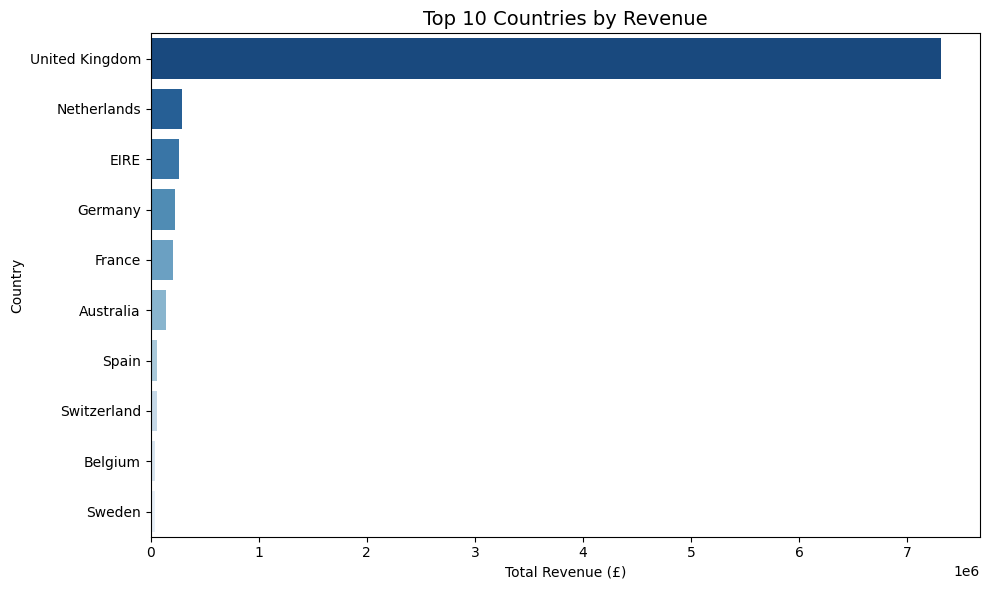

In [53]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))
sns.barplot(x=country_revenue.values, y=country_revenue.index, palette='Blues_r')
plt.title('Top 10 Countries by Revenue', fontsize=14)
plt.xlabel('Total Revenue (£)')
plt.ylabel('Country')
plt.tight_layout()
plt.savefig('../visuals/revenue_by_country.png')
plt.show()

C:\Users\HP\AppData\Local\Temp\ipykernel_15884\3942127607.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_products.values, y=top_products.index, palette='Greens_r')


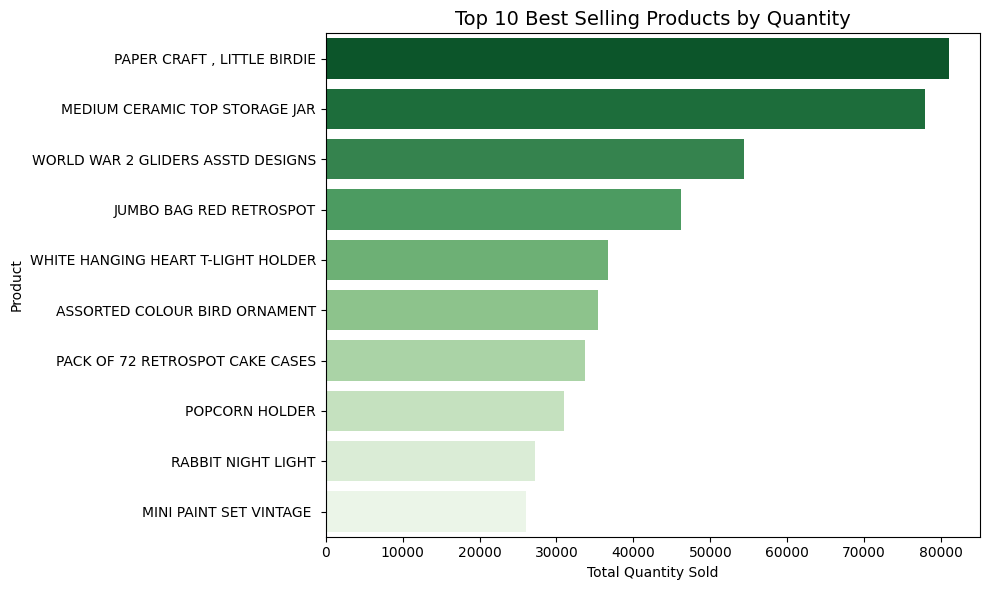

In [54]:
plt.figure(figsize=(10,6))
sns.barplot(x=top_products.values, y=top_products.index, palette='Greens_r')
plt.title('Top 10 Best Selling Products by Quantity', fontsize=14)
plt.xlabel('Total Quantity Sold')
plt.ylabel('Product')
plt.tight_layout()
plt.savefig('../visuals/top_products.png')
plt.show()

This chart reveals monthly revenue patterns over time, highlighting seasonal peaks (particularly November for holiday shopping) and troughs for strategic business planning.

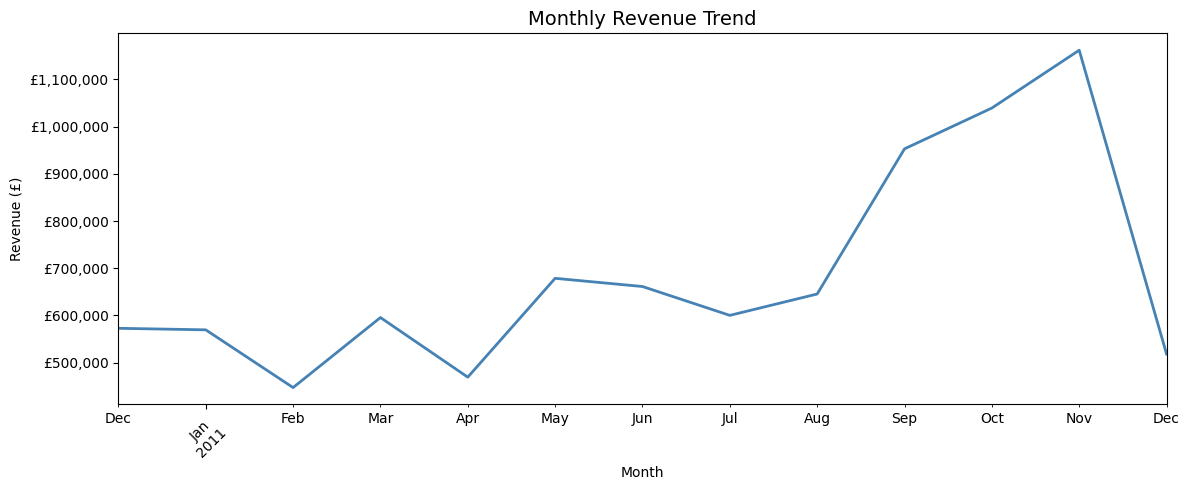

In [55]:
plt.figure(figsize=(12,5))
monthly_revenue.plot(kind='line', color='steelblue', linewidth=2)
plt.title('Monthly Revenue Trend', fontsize=14)
plt.xlabel('Month')
plt.ylabel('Revenue (£)')
plt.xticks(rotation=45)
plt.gca().yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, p: f'£{x:,.0f}')
)
plt.tight_layout()
plt.savefig('../visuals/monthly_revenue_trend.png')
plt.show()

This chart shows the 10 best-selling products by quantity, identifying which items are driving the highest sales volume.

This chart displays the top 10 countries ranked by total revenue, revealing significant geographical concentration with the UK dominating the market.

In [56]:
UK_Revenue_Prcentage = df[df['Country'] == 'United Kingdom']['Revenue'].sum()/df.Revenue.sum() * 100
print(f"UK Revenue Percentage: {UK_Revenue_Prcentage:.2f}%")

UK Revenue Percentage: 82.01%


# Key Business Insights for Store Management
1. **Geographic Revenue Concentration Presents Both Opportunity and Risk**
The UK dominates our revenue generation at £7.3M, while the Netherlands generates just £285K—a 25x difference. This concentration is a double-edged sword. While the UK is clearly our most developed market, it also creates vulnerability if anything disrupts that region. I recommend a strategic push into secondary markets: the Netherlands, Germany, and EIRE show promise but are severely under-resourced relative to their market potential.
2. **Best-Seller Analysis Requires Profitability Review**
Our top products drive significant volume, which is excellent for market presence and operational efficiency. However, volume ≠ profit. Before expanding production or marketing support, we need to verify margins on these best sellers. Some high-volume products may have thin margins that don't justify warehouse space or fulfillment complexity.
3. **Strong Seasonal Patterns Demand Better Planning**
The data reveals distinct seasonality with November 2011 emerging as our peak revenue month, indicating strong Christmas buying behavior. This seasonal pattern should directly influence our inventory purchasing, staffing levels, and marketing budget allocation. We should front-load inventory and marketing spend in Q3 to maximize Q4 sales, then plan for leaner periods in January-March.
4. **UK Revenue Dominance Creates Critical Risk**
The UK represents 82% of total revenue, creating dangerous geographic concentration. A single market disruption — economic, political, or competitive — could devastate the business. International diversification is not optional, it's urgent.

In [57]:
# Export 1 - Revenue by Country
country_revenue.reset_index().to_csv('../data/exports/country_revenue.csv', index=False)

# Export 2 - Monthly Revenue
monthly_revenue.reset_index().to_csv('../data/exports/monthly_revenue.csv', index=False)

# Export 3 - Top Products
top_products.reset_index().to_csv('../data/exports/top_products.csv', index=False)